## 统计分析

通过指定统计分析字段，得到每个特征的p_value，所有的p_value计算都是基于Ttest计算。支持指定不同的分组`group`，例如train、val、test等分组统计。

对于两大类不同的特征

1. 离散特征，统计数量以及占比。
2. 连续特征，统计均值、方差。

In [1]:
import pandas as pd
import numpy as np
from onekey_algo import OnekeyDS as okds
from onekey_algo import get_param_in_cwd
from onekey_algo.custom.utils import print_join_info

task = get_param_in_cwd('task_column') or 'label'
p_value = get_param_in_cwd('p_value') or 0.05
# 修改成自己临床数据的文件。
test_data = pd.read_csv(get_param_in_cwd('clinic_file'))
stats_columns_settings = get_param_in_cwd('stats_columns')
continuous_columns_settings = get_param_in_cwd('continuous_columns')
mapping_columns_settings = get_param_in_cwd('mapping_columns')
test_data = test_data[[c for c in test_data.columns if c != task]]
test_data['ID'] = test_data['ID'].map(lambda x: f"{x}.nii.gz" if not (f"{x}".endswith('.nii.gz') or  f"{x}".endswith('.nii')) else x)
group_info = pd.read_csv(get_param_in_cwd('label_file'))
print_join_info(test_data, group_info)
test_data = pd.merge(test_data, group_info, on='ID', how='inner')
test_data

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\\\Users\\\\cxw\\\\Desktop\\\\sci_immune\\\\ALL\\\\mutil\\\\models\\\\new_clinical\\\\data(sheet2)插补完.csv'

# 特征名称处理

去掉所有特征名称中的特殊字符。

In [2]:
import re

def map_cnames(x):
    x = re.split('[（|(]', x)[0]
    x = x.replace('-', '_').replace(' ', '_').replace('>', '').replace('/', '_')
    return x.strip()

test_data.columns = list(map(map_cnames, test_data.columns))
test_data.columns

Index(['ID', 'lab', 'duration', 'event', 'HPV_status', 'diameter_primary',
       'enhancement', 'diameter', 'necrosis', 'gender', 'age', 'smoking',
       'drinking', 'immule', 'Pre_T', 'Pre_N', 'Pos_T', 'Pos_N', 'cancer',
       'grade', 'label', 'group'],
      dtype='object')

# 分析数据

获取待分析的特征列名，如未制定，自动侦测。

In [8]:
stats_columns = stats_columns_settings or list(test_data.columns[1:-2])
test_data = test_data.copy()[['ID'] + stats_columns + ['group', 'label']]
test_data

,ID,lab,duration,event,HPV_status,diameter_primary,enhancement,diameter,necrosis,gender,...,drinking,immule,Pre_T,Pre_N,Pos_T,Pos_N,cancer,grade,group,label
0,2.nii.gz,0,41,0,1,11,0,11,0,2,...,1,2,1,3,1,3,5,2,train,0
1,3.nii.gz,0,41,0,0,28,0,28,0,2,...,1,2,2,0,2,0,1,2,train,0
2,27.nii.gz,0,3,1,1,23,0,23,0,2,...,1,2,3,1,1,3,4,2,train,0
3,5.nii.gz,0,29,0,0,38,1,38,0,2,...,0,2,4,2,4,2,1,2,test,0
4,6.nii.gz,0,36,0,1,51,0,51,0,2,...,1,2,4,3,2,1,2,2,train,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,235.nii.gz,0,32,0,0,29,0,29,0,2,...,1,2,3,1,3,2,1,1,train,0
177,185.nii.gz,0,36,1,0,67,1,67,0,2,...,1,1,4,2,4,2,1,3,train,0
178,117.nii.gz,1,38,1,0,12,0,12,0,2,...,0,2,2,0,0,0,5,2,test,1
179,242.nii.gz,1,20,0,0,36,1,36,0,2,...,0,2,4,2,3,2,1,3,train,1


# 特征队列映射

所有需要进行特征映射的队列，range未制定，可以进行自动判断。

In [9]:
mapping_columns = mapping_columns_settings or [c for c in test_data.columns[1:-2] if test_data[c].dtype == object]
mapping_columns

[]

# 数据映射

针对所有非数值形式的数据，可以进行类别映射。

In [10]:
from onekey_algo.custom.utils import map2numerical

data, mapping = map2numerical(test_data, mapping_columns=mapping_columns)
mapping

{}

In [11]:
from onekey_algo.custom.components.comp1 import fillna

data = fillna(data, fill_mod='50%')
continuous_columns = []
for col in test_data.columns:
    if test_data[col].apply(lambda x: x.is_integer() if isinstance(x, float) else False).all():
        test_data[col] = test_data[col].astype(int)

for c in stats_columns:
#     print(c, np.unique(test_data[c]), test_data[c].dtype)
    if len(np.unique(test_data[c])) > 5 or not np.int8 <= test_data[c].dtype <= np.int64:
        continuous_columns.append(c)
        
continuous_columns = continuous_columns_settings or continuous_columns
continuous_columns = [c for c in continuous_columns if c not in ('differentation')]
continuous_columns

['duration', 'diameter_primary', 'diameter', 'age']

# 缺失值填充

In [12]:
import os
os.makedirs('data', exist_ok=True)
data.to_csv('data/clinical.csv', index=False)
data

,ID,lab,duration,event,HPV_status,diameter_primary,enhancement,diameter,necrosis,gender,...,drinking,immule,Pre_T,Pre_N,Pos_T,Pos_N,cancer,grade,group,label
0,2.nii.gz,0,41,0,1,11,0,11,0,2,...,1,2,1,3,1,3,5,2,train,0
1,3.nii.gz,0,41,0,0,28,0,28,0,2,...,1,2,2,0,2,0,1,2,train,0
2,27.nii.gz,0,3,1,1,23,0,23,0,2,...,1,2,3,1,1,3,4,2,train,0
3,5.nii.gz,0,29,0,0,38,1,38,0,2,...,0,2,4,2,4,2,1,2,test,0
4,6.nii.gz,0,36,0,1,51,0,51,0,2,...,1,2,4,3,2,1,2,2,train,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
176,235.nii.gz,0,32,0,0,29,0,29,0,2,...,1,2,3,1,3,2,1,1,train,0
177,185.nii.gz,0,36,1,0,67,1,67,0,2,...,1,1,4,2,4,2,1,3,train,0
178,117.nii.gz,1,38,1,0,12,0,12,0,2,...,0,2,2,0,0,0,5,2,test,1
179,242.nii.gz,1,20,0,0,36,1,36,0,2,...,0,2,4,2,3,2,1,3,train,1


### 统计分析

支持两种格式数据，分别对应`pretty`参数的`True`和`False`, 当为`True`时，输出的是表格模式，反之则为dict数据。

```python
def clinic_stats(data: DataFrame, stats_columns: Union[str, List[str]], label_column='label',
                 group_column: str = None, continuous_columns: Union[str, List[str]] = None,
                 pretty: bool = True) -> Union[dict, DataFrame]:
    """

    Args:
        data: 数据
        stats_columns: 需要统计的列名
        label_column: 二分类的标签列，默认`label`
        group_column: 分组统计依据，例如区分训练组、测试组、验证组。
        continuous_columns: 那些列是连续变量，连续变量统计均值方差。
        pretty: bool, 是否对结果进行格式美化。

    Returns:
        stats DataFrame or json

    """
```

In [13]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column=task, 
                     group_column='group', 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
stats.to_csv(f'data/stats_{task}.csv', index=False, encoding='utf_8_sig')
stats

,feature_name,train-label=ALL,train-label=0,train-label=1,pvalue,test-label=ALL,test-label=0,test-label=1,pvalue
0,duration,20.186±10.690,19.922±11.274,20.683±9.611,0.399,19.619±12.278,18.780±12.154,21.182±12.640,0.399
1,diameter_primary,41.576±16.532,42.338±17.088,40.146±15.540,0.593,41.984±15.207,42.585±14.142,40.864±17.313,0.629
2,diameter,41.000±15.151,41.584±15.106,39.902±15.362,0.593,41.825±14.906,42.341±13.647,40.864±17.313,0.649
3,age,62.483±9.933,62.636±10.147,62.195±9.634,0.819,62.238±9.416,61.951±9.997,62.773±8.423,0.744
0,lab,,,,<0.001,,,,<0.001
1,0,77(65.254),77(100.000),null,,41(65.079),41(100.000),null,
2,1,41(34.746),null,41(100.000),,22(34.921),null,22(100.000),
3,event,,,,0.056,,,,1.0
4,0,74(62.712),43(55.844),31(75.610),,37(58.730),24(58.537),13(59.091),
5,1,44(37.288),34(44.156),10(24.390),,26(41.270),17(41.463),9(40.909),


In [14]:
from onekey_algo.custom.components.stats import clinic_stats

pd.set_option('display.max_rows', None)
stats = clinic_stats(data, 
                     stats_columns= stats_columns,
                     label_column='group', 
                     group_column=None, 
                     continuous_columns= continuous_columns, 
                     pretty=True, verbose=False)
stats.to_csv('data/statics.csv', index=False, encoding='utf_8_sig')
stats

,feature_name,-label=ALL,-label=test,-label=train,pvalue
0,duration,19.989±11.237,19.619±12.278,20.186±10.690,0.416
1,diameter_primary,41.718±16.042,41.984±15.207,41.576±16.532,0.745
2,diameter,41.287±15.030,41.825±14.906,41.000±15.151,0.692
3,age,62.398±9.731,62.238±9.416,62.483±9.933,0.872
0,lab,,,,1.0
1,0,118(65.193),41(65.079),77(65.254),
2,1,63(34.807),22(34.921),41(34.746),
3,event,,,,0.716
4,0,111(61.326),37(58.730),74(62.712),
5,1,70(38.674),26(41.270),44(37.288),


# 单因素多因素分析

单因素，步进多因素分析
```python
def uni_multi_variable_analysis(data: pd.DataFrame, features: Union[str, List[str]] = None, label_column: str = 'label',
                                need_norm: Union[bool, List[bool]] = False, alpha=0.1,
                                p_value4multi: float = 0.05, save_dir: Union[str] = None, prefix: str = '',
                                **kwargs):
    """
    单因素，步进多因素分析，使用p_value4multi参数指定多因素分析的阈值
    Args:
        data: 数据
        features: 需要分析的特征，默认除了ID和label_column列，其他的特征都进行分析。
        label_column: 目标列
        need_norm: 是否标准化所有分析的数据, 默认为False
        alpha: CI alpha, alpha/2 %；默认为0.1即95% CI
        p_value4multi: 参数指定多因素分析的阈值，默认为0.05
        save_dir: 保存位置
        prefix: 前缀
        **kwargs:

    Returns:

    """
 ```

,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
lab,34.406,-7.710e+06,7.710e+06,8.761e+14,0.000,inf,1.000
duration,-0.023,-3.800e-02,-9.000e-03,9.770e-01,0.963,0.991,0.007
event,-1.224,-1.815e+00,-6.320e-01,2.940e-01,0.163,0.532,0.001
HPV_status,-0.383,-9.340e-01,1.680e-01,6.820e-01,0.393,1.183,0.253
diameter_primary,-0.014,-2.200e-02,-7.000e-03,9.860e-01,0.978,0.993,0.001
enhancement,-0.480,-8.620e-01,-9.900e-02,6.180e-01,0.422,0.906,0.038
diameter,-0.015,-2.200e-02,-7.000e-03,9.860e-01,0.978,0.993,0.001
necrosis,-0.134,-9.850e-01,7.180e-01,8.750e-01,0.373,2.05,0.796
gender,-0.333,-4.970e-01,-1.690e-01,7.170e-01,0.608,0.845,0.001


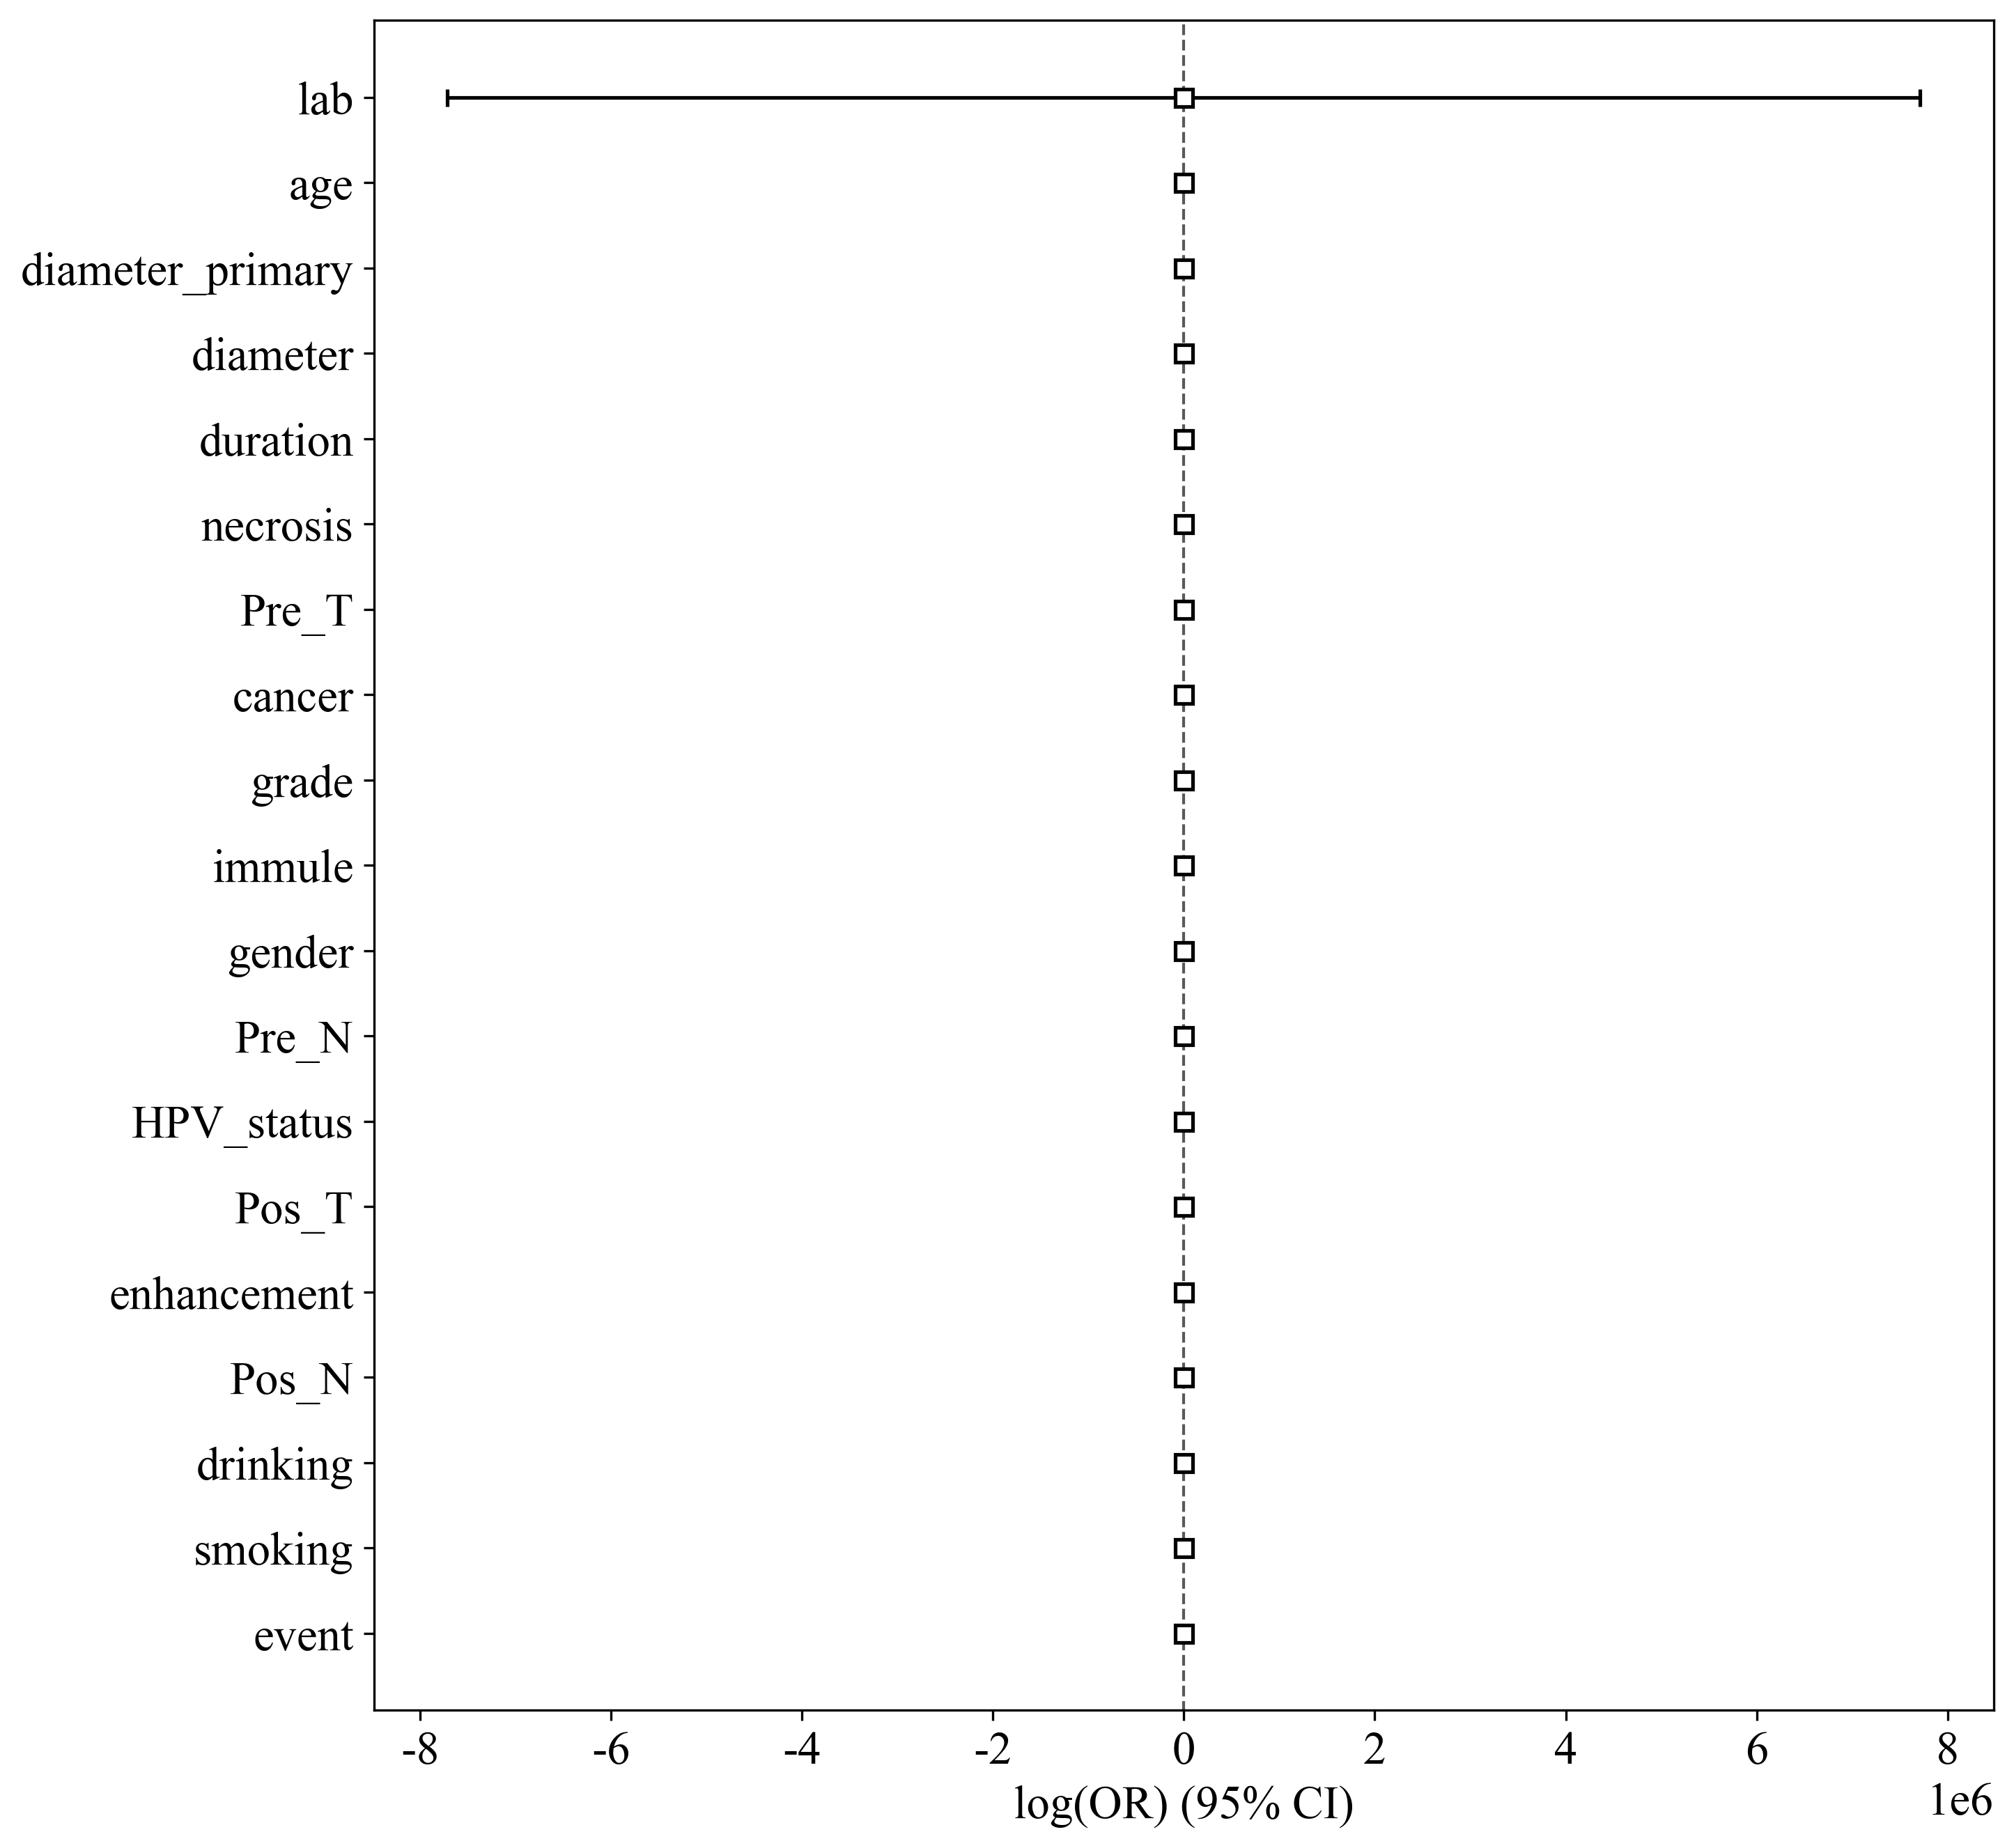

Optimization terminated successfully.
         Current function value: 0.527123
         Iterations 6


,Log(OR),lower 95%CI,upper 95%CI,OR,OR lower 95%CI,OR upper 95%CI,p_value
feature_name,,,,,,,
event,-0.764,-1.732,0.205,0.466,0.177,1.228,0.195
smoking,-1.611,-2.839,-0.383,0.200,0.058,0.682,0.031
drinking,0.424,-0.581,1.428,1.528,0.559,4.170,0.488
Pos_N,-0.431,-0.914,0.053,0.650,0.401,1.054,0.143
enhancement,-0.079,-0.654,0.495,0.924,0.520,1.640,0.820
Pos_T,-0.612,-0.975,-0.250,0.542,0.377,0.779,0.006
Pre_N,-0.099,-0.540,0.343,0.906,0.583,1.409,0.713
gender,0.026,-1.278,1.330,1.026,0.279,3.781,0.974
immule,0.598,-0.369,1.564,1.818,0.691,4.778,0.309


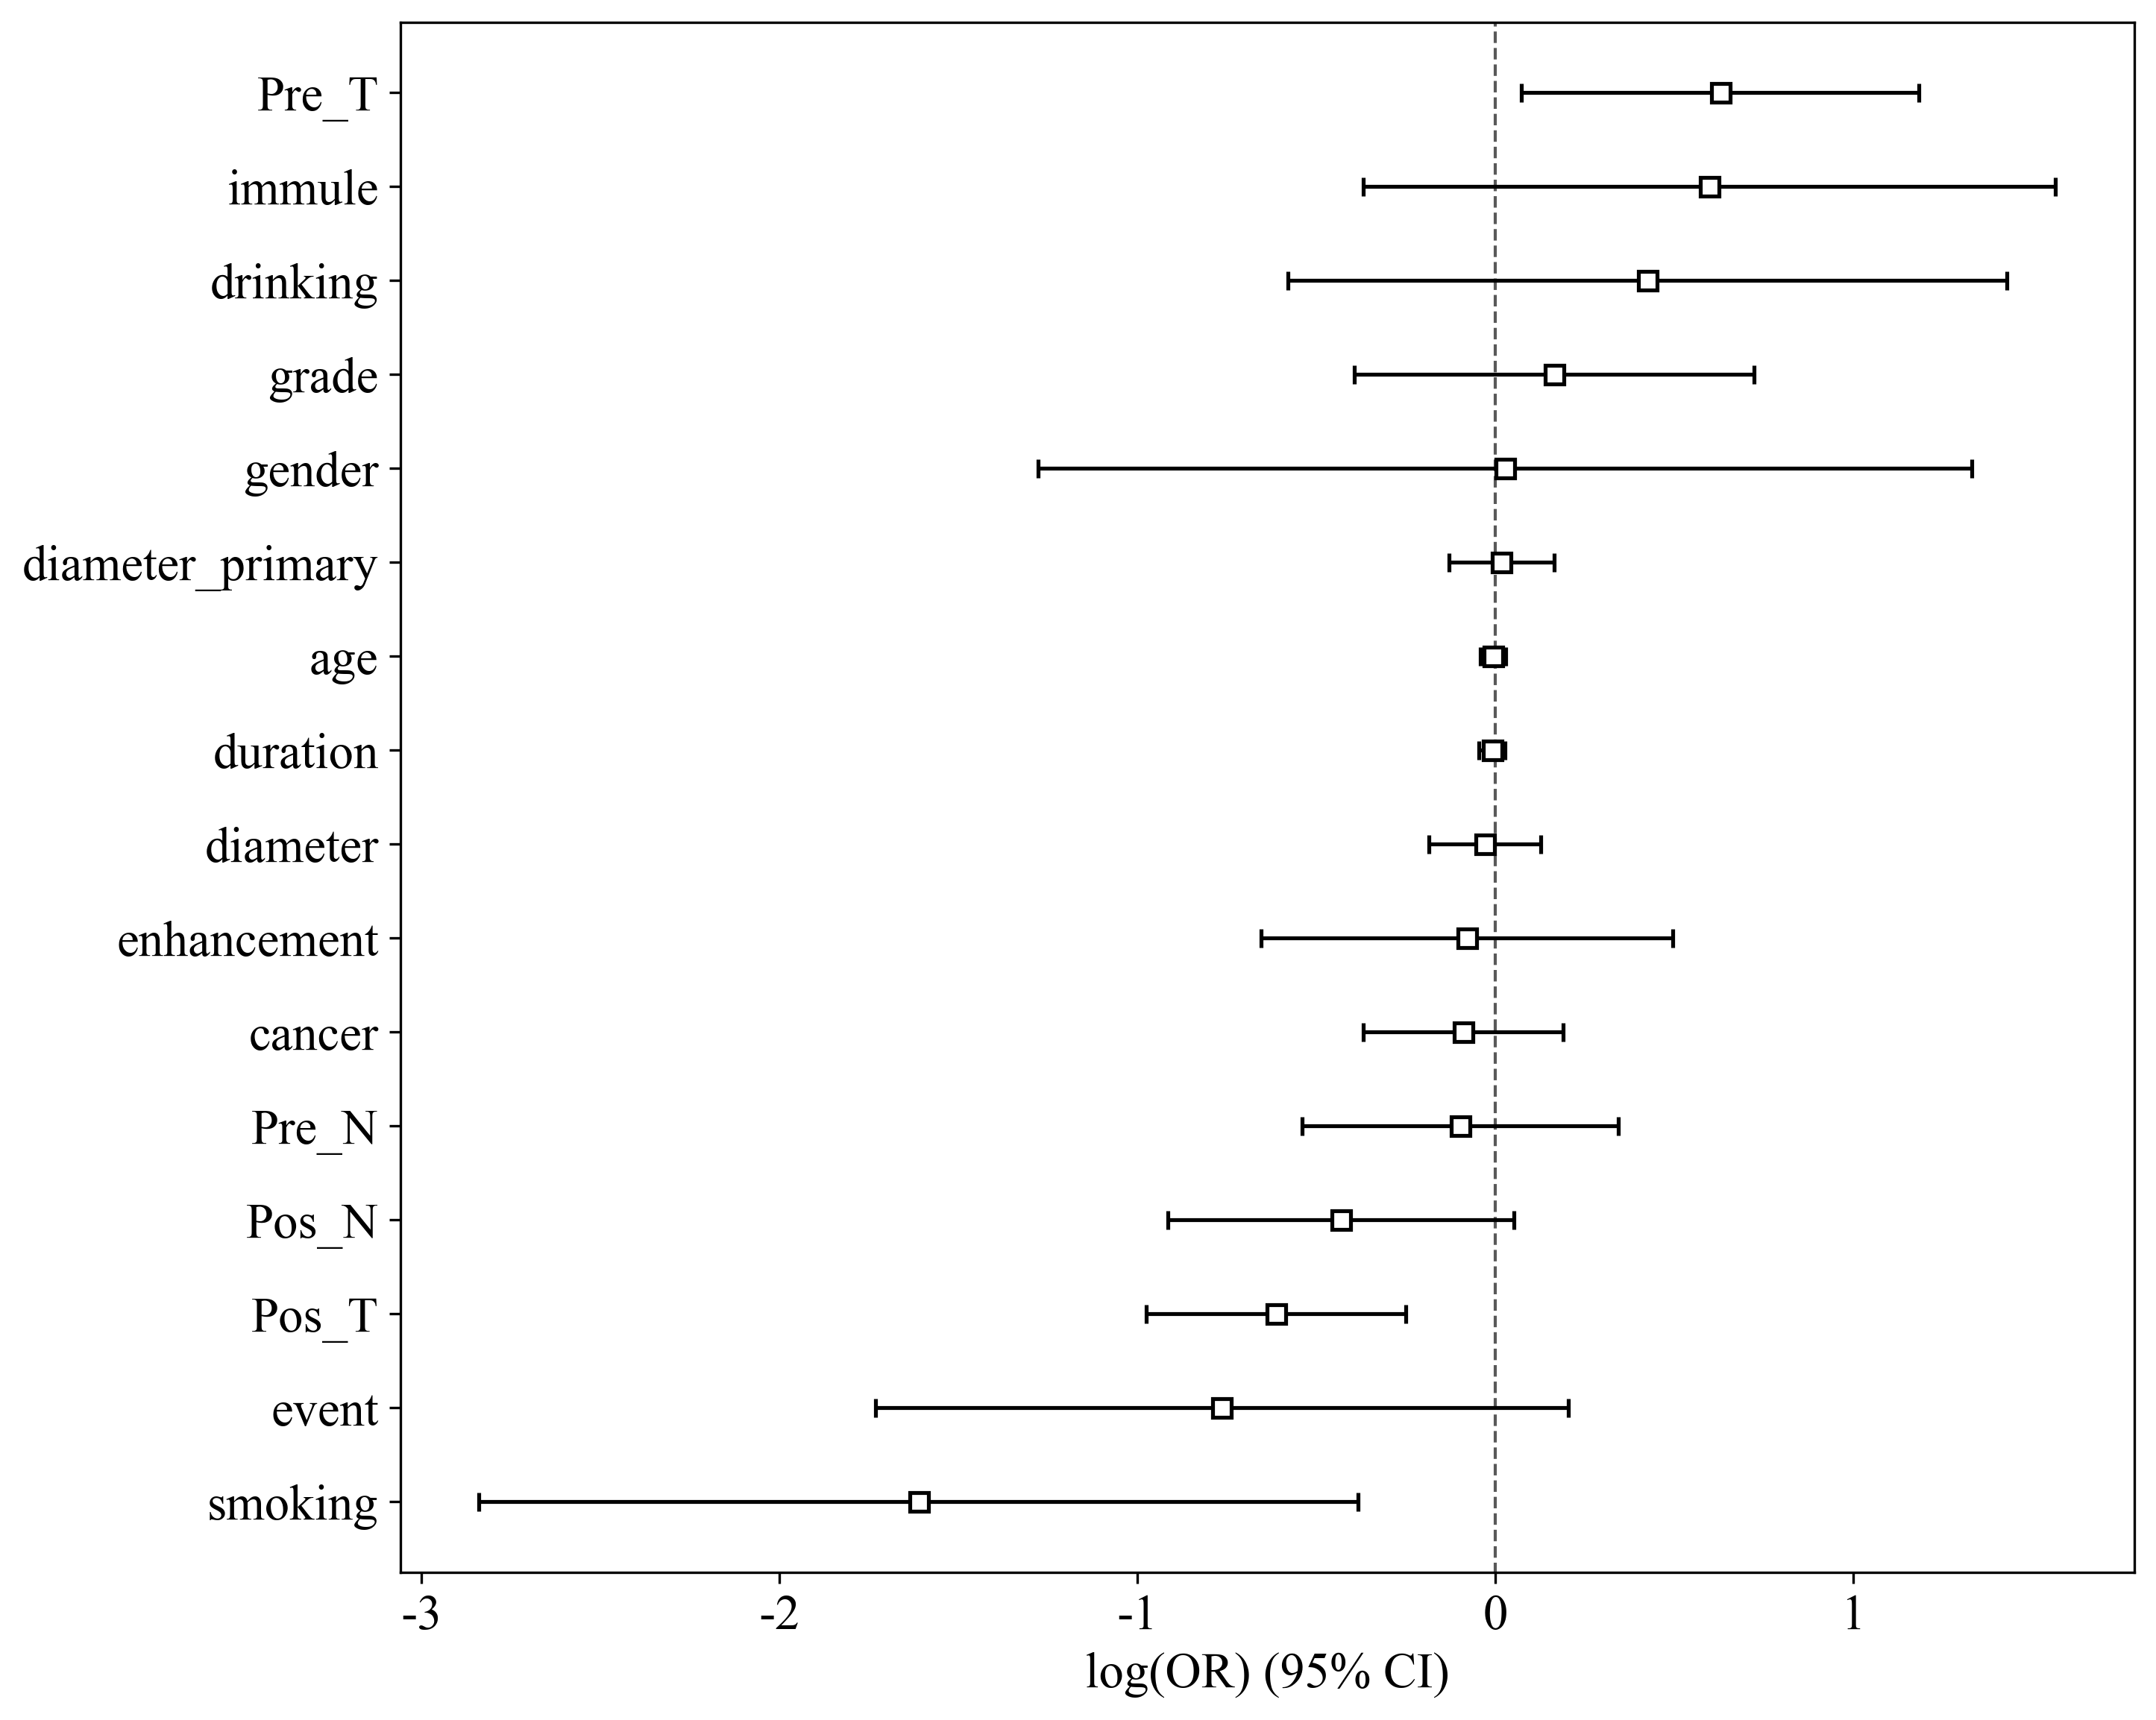

In [15]:
from onekey_algo.custom.components.comp1 import uni_multi_variable_analysis                        

uni_multi_variable_analysis(data[data['group'] == 'train'], stats_columns, save_dir='img', p_value4multi=p_value, algo='logit')

In [16]:
uni_v = pd.read_csv('img/multivariable_reg.csv')
uni_v = uni_v[uni_v['p_value'] <= 0.05]
sel_data = data[['ID'] + list(uni_v['feature_name']) + ['group', 'label']]
sel_data.to_csv('data/clinic_sel.csv', index=False)
sel_data

,ID,smoking,Pos_T,group,label
0,2.nii.gz,1,1,train,0
1,3.nii.gz,1,2,train,0
2,27.nii.gz,1,1,train,0
3,5.nii.gz,1,4,test,0
4,6.nii.gz,1,2,train,0
5,7.nii.gz,0,1,test,0
6,8.nii.gz,0,0,test,0
7,9.nii.gz,0,1,train,1
8,10.nii.gz,1,2,test,0
9,56.nii.gz,1,3,test,1


In [17]:
uni = pd.read_csv('img/univariable_reg.csv')
uni = uni[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
multi = pd.read_csv('img/multivariable_reg.csv')
multi = multi[[c for c in uni if ('OR' in c and 'Log' not in c) or c in ['feature_name', 'p_value']]]
info = pd.merge(uni, multi, on='feature_name', how='left', suffixes=['_UNI', '_MULTI']).applymap(lambda x: '' if pd.isna(x) else x)
info.to_csv('results/unimulti.csv', index=False)
info

,feature_name,OR_UNI,OR lower 95%CI_UNI,OR upper 95%CI_UNI,p_value_UNI,OR_MULTI,OR lower 95%CI_MULTI,OR upper 95%CI_MULTI,p_value_MULTI
0,event,2.940e-01,0.163,0.532,0.001,0.466,0.177,1.228,0.195
1,smoking,4.060e-01,0.277,0.596,0.000,0.2,0.058,0.682,0.031
2,drinking,4.440e-01,0.297,0.666,0.001,1.528,0.559,4.17,0.488
3,Pos_N,5.770e-01,0.460,0.725,0.000,0.65,0.401,1.054,0.143
4,enhancement,6.180e-01,0.422,0.906,0.038,0.924,0.52,1.64,0.82
5,Pos_T,6.490e-01,0.542,0.776,0.000,0.542,0.377,0.779,0.006
6,HPV_status,6.820e-01,0.393,1.183,0.253,,,,
7,Pre_N,6.920e-01,0.581,0.824,0.001,0.906,0.583,1.409,0.713
8,gender,7.170e-01,0.608,0.845,0.001,1.026,0.279,3.781,0.974
9,immule,7.360e-01,0.621,0.872,0.003,1.818,0.691,4.778,0.309
